<a href="https://colab.research.google.com/github/chaitanysaraswat/Advanced-Analytics-Using-Statistics/blob/main/lecture21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

# TIME SERIES:

- X WILL BE TIME FACTOR MONTH YEAR MIN Y QUANTITY SALES QUANTITY

-3 VARIATION RANDOM TREND SEASONAL VARIATION     
- YOU WILL GET BEST FIT LINE UP
- SEASONAL VARIATION PATTERN REPEATING AFTER INTREVAL OF TIME
- RANDOM VARIATION DON'T WORRY AND DON'T WANT TO KNOW
- TREND HOUSE PRICES,FMCG PRODUCT
- SEASONAL NO TREND WEATHER TEMPERATURE
- TREND AND SEASONALLY: SALE SWEATER RAINCOAT
-  HOW TO FILL NA TAKE PREVIOUS NUMBER AND AFTER THAT NUMBER TAKE AVG OF THAT NUMBER



types of error

- take avg of all errors  (we can take sum bcoz summation will give zero)
- mean absolute error summation of absolute errors.
- mse mean squared error  error^2 problem is square of original error
- mean absolute percentage error(mape) pro dimensionless quantity
- root mean square error(rmse) unit is same **as** original data

<Axes: >

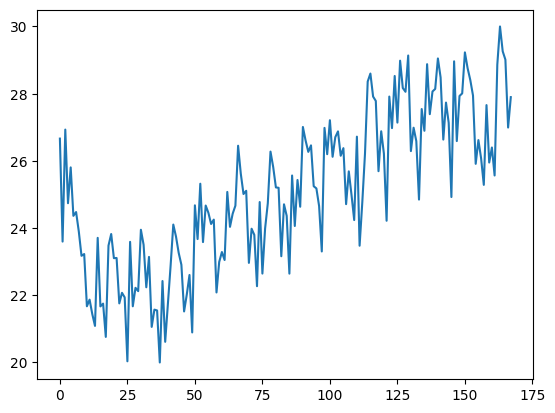

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt
df=pd.read_excel('/content/drive/MyDrive/CDAC_stats/CDAC_DataBook.xlsx',sheet_name='birth')
df.BirthRate.plot()

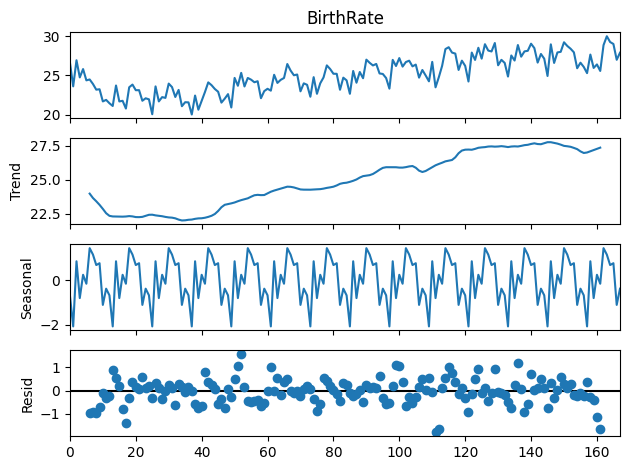

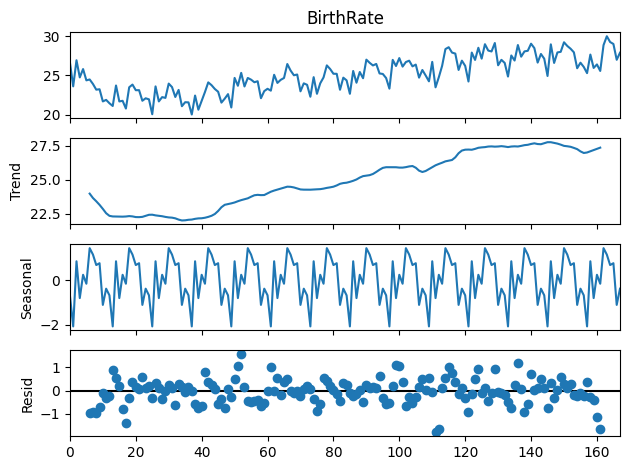

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose as ssd
ssd(df.BirthRate,period=12).plot()

In [8]:
df.head()

,BirthRate
0,26.663
1,23.598
2,26.931
3,24.740
4,25.806


NAIVE METHOD:

In [10]:
df_train=df.iloc[:144]
df_test=df.iloc[144:]

df_test['naive']=df_train.BirthRate.iloc[-1]
sqrt(mean_squared_error(df_test.BirthRate,df_test.naive))

1.4277309211939526

In [12]:

df_test['SimpAvg']=df_train.BirthRate.mean()
sqrt(mean_squared_error(df_test.BirthRate,df_test.SimpAvg))

3.147657647627305

In [13]:
# 12 months moving average
df_test['12MthsMovingAvg'] = df_train.BirthRate.iloc[-12:].mean()
sqrt(mean_squared_error(df_test.BirthRate, df_test['12MthsMovingAvg']))
# 1.40448108

# 24 months moving average
df_test['24MthsMovingAvg'] = df_train.BirthRate.iloc[-24:].mean()
sqrt(mean_squared_error(df_test.BirthRate, df_test['24MthsMovingAvg']))
# 1.40386

1.4038687245726835

moving avg chart will cut down across duration
std will be less as time period increases easy to take decision


| Values (x) | Weight (w) | x × w |
|------------|------------|-------|
| 19         | 2          | 38    |
| 17         | 3          | 51    |
| 28         | 4          | 112   |
| 25         | 6          | 150   |
| 36         | 8          | 288   |
| 16         | 10         | 160   |
| **Total**  | **33**     | **799** |

### Weighted Mean Calculation



In [23]:
# 12 months weighted moving average
wts = np.arange(12,0,-1)
df_test['WMA']  = (sum(df_train.BirthRate.iloc[-12:]*wts))/sum(wts)
sqrt(mean_squared_error(df_test.BirthRate, df_test.WMA))

1.4238115558763185

| Sales (A) | Forecast (F) | Calculation |
|------------|------------|-------------|
| 7 | - | Initial value |
| 6 | 7.0 | Initial forecast |
| 8 | 6.2 | (0.8 × 6) + (0.2 × 7) = 6.2 |
| 5 | 7.6 | (0.8 × 8) + (0.2 × 6.2) = 7.64 ≈ 7.6 |
| 9 | 5.5 | (0.8 × 5) + (0.2 × 7.6) = 5.52 ≈ 5.5 |

### Exponential Smoothing Formula

\[
F_t = \alpha A_{t-1} + (1-\alpha)F_{t-1}
\]

where:

- \(F_t\) = Forecast for current period
- \(A_{t-1}\) = Actual sales from previous period
- \(F_{t-1}\) = Forecast from previous period
- \(\alpha = 0.8\)

80 percentage  weight true value 20% weightage to predicted value
### Calculation

\[
F_3 = (0.8 \times 6) + (0.2 \times 7) = 6.2
\]

\[
F_4 = (0.8 \times 8) + (0.2 \times 6.2) = 7.64 \approx 7.6
\]

\[
F_5 = (0.8 \times 5) + (0.2 \times 7.6) = 5.52 \approx 5.5
\]

In [26]:
x1=np.array([7,6,8,5,9,7,5,7,6,8,9,4,6,5,6])
from statsmodels.tsa.api import SimpleExpSmoothing
mod1 = SimpleExpSmoothing(x1).fit(smoothing_level=0.8, optimized=False)
mod1.forecast(1)

array([5.83156084])

In [27]:
# Simple Exponential Smoothing
mod1 = SimpleExpSmoothing(df_train.BirthRate).fit(smoothing_level=0.8, optimized=False)
df_test['SES'] = mod1.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.SES))
# 1.40862

1.4086237555629835

In [29]:
# holt's linear trend mehod when we have only trend  and no  seasonal variations
from statsmodels.tsa.api import Holt
mod2 = Holt(df_train.BirthRate).fit(smoothing_level=0.8)
df_test['HoltLinear'] = mod2.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.HoltLinear))

1.500895536001304

In [32]:
# Holt-Winter's method - used when we have both trend and seasonal variation
from statsmodels.tsa.api import ExponentialSmoothing
mod3 = ExponentialSmoothing(df_train.BirthRate,seasonal_periods=12).fit()
df_test['HoltWinter'] = mod3.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.HoltWinter))
# 1.420764


1.4207646015778608

ARIMA:-interview within LSTM
- AUTO REGRESSIVE INTEGERATED MOVING AVERAGE
- THIS MODEL WHEN IS USED WHEN THE TIME SERIES IS STATIONARY
- FOR TIME SERIE S TO BE STSTIONARY:  MEAN CONSTANT AND VARIANCE ARE CONSTANT




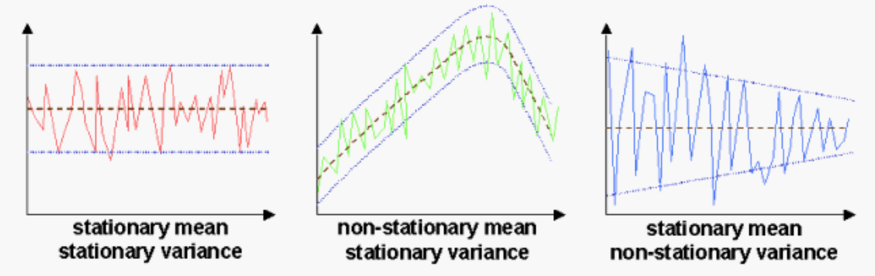

IF THE ORIGINAL IS NOT STATIONARY THEN WE CREATE NEW SERIES BY TAKING

DIFFERENCE OF THE CONSEQUTIVE VALUES OF ORIGINAL TIME-SEIES AND THEN THIS NEW
SERIES IS CHECK WHETHER IS STATIONARY OR NOT
IF NOT THEN SECOND LEVEL OF REFERECING IS DONE IT WILL CONTINUE UNTIL STATIONARY VALUES ARE FOUND

p pacf plot direct relationship not transit relationhip after t
d differencing
q after how many lags it it insignificant


AD FULLER TEST ⁉

- IS USED WHEN TO CHECK WHETHER THE TIME SERIES STATIONRY OR NOT THE NULL HYPOTHESIS IN THIS CASE IS THAT THE TIME SERIES IS NON STATIONARY

### Autocorrelation Lag Table

| Period | Sales (Lag 0) | Lag 1 | Lag 2 |
|---------|---------|-------|-------|
| Jan | 5 | - | - |
| Feb | 6 | 5 | - |
| Mar | 9 | 6 | 5 |
| Apr | 4 | 9 | 6 |
| May | 7 | 4 | 9 |
| Jun | 6 | 7 | 4 |
| Jul | 8 | 6 | 7 |
| Aug | - | 8 | 6 |
| Sep | - | - | 8 |

AND PARTIAL AUTO COREALTION PLOT:ONLY DIRECT WAY TO GO
-  

In [33]:
from statsmodels.tsa.stattools import adfuller
adfuller(df_train)
df_train1 = df_train.diff().dropna()
adfuller(df_train1)

(np.float64(-4.253904918858687),
 np.float64(0.0005333378978881231),
 14,
 128,
 {'1%': np.float64(-3.4825006939887997),
  '5%': np.float64(-2.884397984161377),
  '10%': np.float64(-2.578960197753906)},
 np.float64(314.64706729275866))

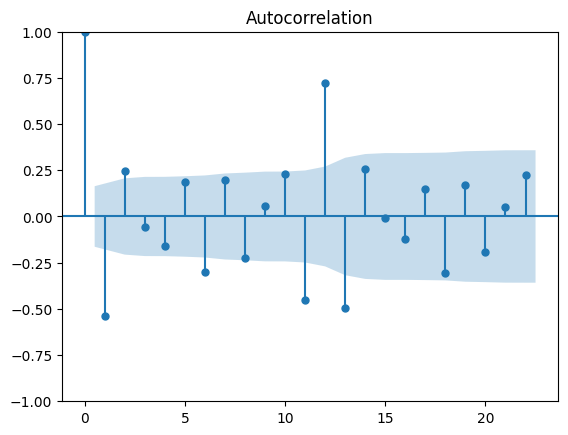

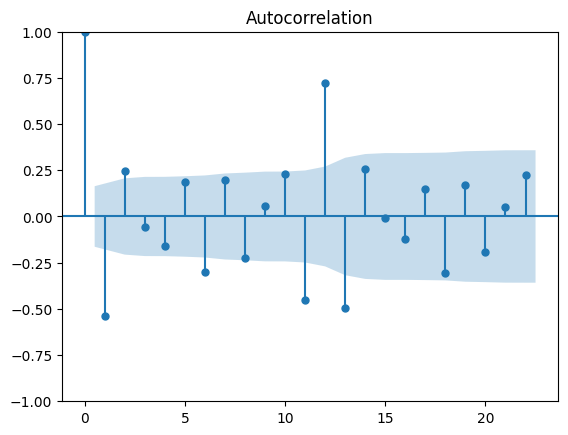

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_train.diff().dropna())   # gives the value of q which is the third number in the order

1.4246485381484106

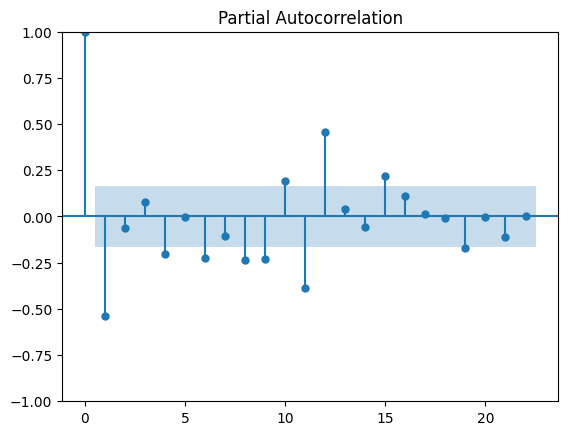

In [37]:
plot_pacf(df_train.diff().dropna())  # gives the value of p which is the first number in the order
# the second number in the order is d which is the number of times the differencing is applied to make a time series stationary

from statsmodels.tsa.arima.model import ARIMA

mod4 = ARIMA(df_train,order=(1,1,2)).fit()
df_test['ARIMA'] = mod4.forecast(24)
sqrt(mean_squared_error(df_test.BirthRate, df_test.ARIMA))
# 1.4246485373